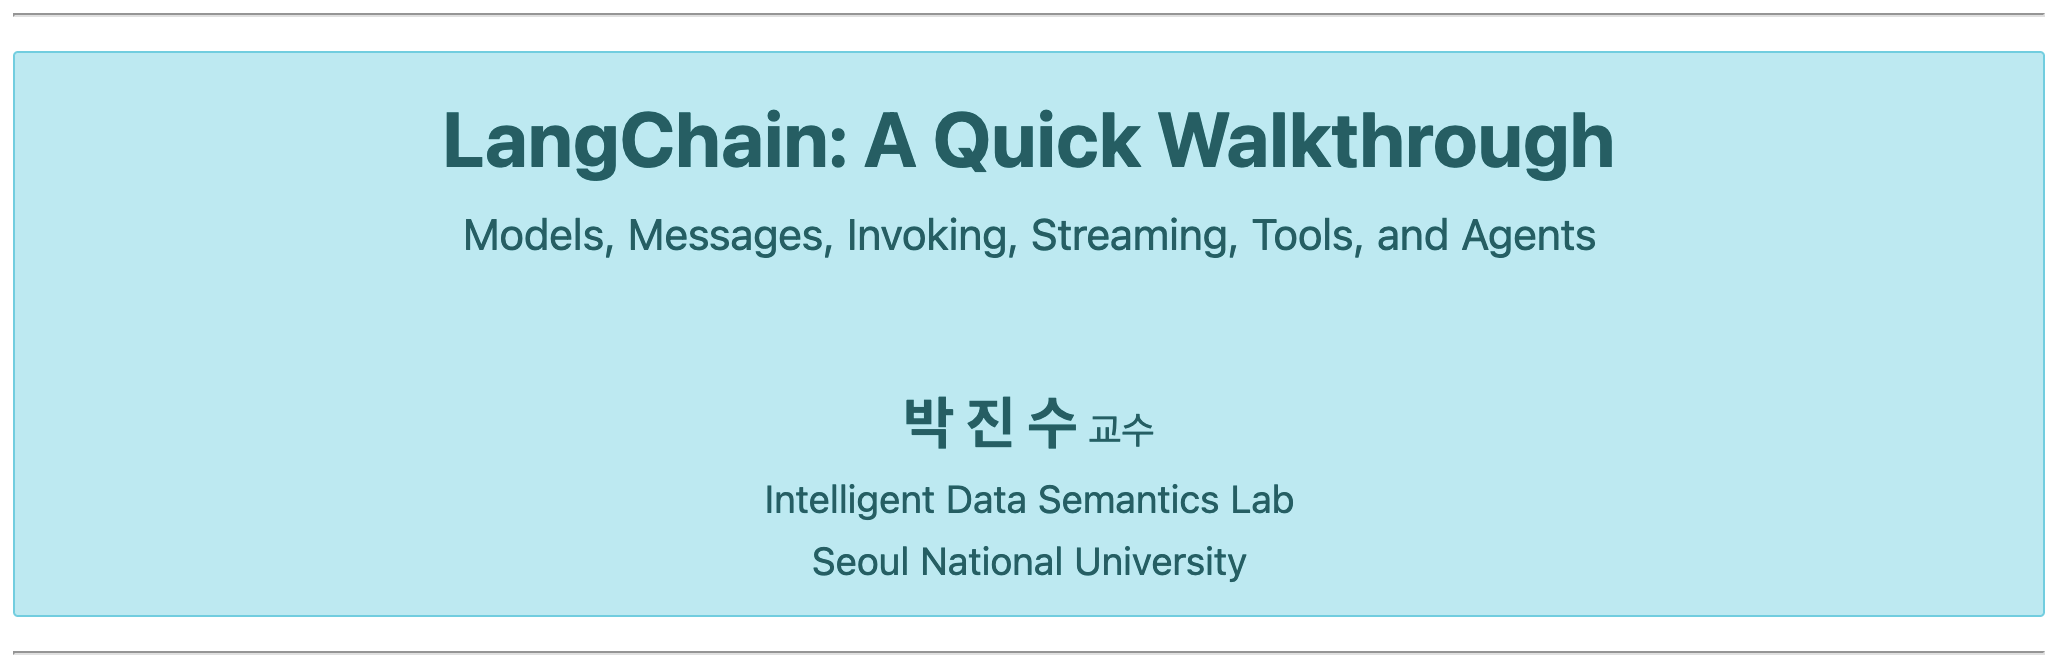

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain이 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#모델---메시지---출력/스트리밍" data-toc-modified-id="모델---메시지---출력/스트리밍-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>모델 - 메시지 - 출력/스트리밍</a></span><ul class="toc-item"><li><span><a href="#모델-초기화" data-toc-modified-id="모델-초기화-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>모델 초기화</a></span></li><li><span><a href="#메시지" data-toc-modified-id="메시지-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>메시지</a></span></li><li><span><a href="#메시지-호출" data-toc-modified-id="메시지-호출-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>메시지 호출</a></span></li><li><span><a href="#메시지-스트리밍" data-toc-modified-id="메시지-스트리밍-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>메시지 스트리밍</a></span></li></ul></li><li><span><a href="#외부-데이터(지식)-사용" data-toc-modified-id="외부-데이터(지식)-사용-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>외부 데이터(지식) 사용</a></span></li><li><span><a href="#도구-사용-모델(에이전트)" data-toc-modified-id="도구-사용-모델(에이전트)-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>도구 사용 모델(에이전트)</a></span><ul class="toc-item"><li><span><a href="#도구-정의" data-toc-modified-id="도구-정의-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>도구 정의</a></span></li><li><span><a href="#모델-초기화" data-toc-modified-id="모델-초기화-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>모델 초기화</a></span></li><li><span><a href="#실행" data-toc-modified-id="실행-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>실행</a></span></li></ul></li><li><span><a href="#기본-제공-에이전트(Built-in-Agent)" data-toc-modified-id="기본-제공-에이전트(Built-in-Agent)-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>기본 제공 에이전트(Built-in Agent)</a></span></li><li><span><a href="#Lab:-현재-디렉토리-파일-목록-도구를-가진-에이전트-만들기" data-toc-modified-id="Lab:-현재-디렉토리-파일-목록-도구를-가진-에이전트-만들기-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Lab: 현재 디렉토리 파일 목록 도구를 가진 에이전트 만들기</a></span></li></ul></div>

# 패키지 설치 및 API 설정

In [ ]:
!python -m pip install -qU python-dotenv requests beautifulsoup4 wikipedia langchain # YOUR LLM package HERE (e.g., ollama 'langchain[ollama]' mistralai 'langchain[mistralai]' groq 'langchain[groq]' google-genai 'langchain[google-genai]' anthropic 'langchain[anthropic]' openai 'langchain[openai]')
print('--- Installation Completed', '-' * 55, '\n')

In [1]:
# 방법 1 (API Key 명칭 수정 후 사용) - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

True

In [ ]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

# 모델 - 메시지 - 출력/스트리밍

## 모델 초기화

- - -
LangChain에서 사용할 수 있는 모델 이름과 형식은 공식 문서에서 확인할 수 있다.
- https://docs.langchain.com/oss/python/integrations/chat
- https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- - -

In [2]:
# --- 모델 초기화
from langchain.chat_models import init_chat_model


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 모델을 바꿔 테스트하려면 init_chat_model을 사용한다.
model = init_chat_model(
    model='openai:gpt-5.4-mini'
)     
google = init_chat_model(
    model='google_genai:gemini-flash-latest' 
)
anthropic = init_chat_model(
    model='anthropic:claude-haiku-4-5', 
    thinking={
        'type': 'enabled', 
        'budget_tokens': 1024
    }, 
    max_tokens=2048
)  

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

## 메시지

In [3]:
# OpenAI 메시지 스타일
model.invoke([{'role': 'user', 'content': '대한민국의 수도는 어디입니까?'}]) 

AIMessage(content='대한민국의 수도는 **서울특별시**입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 15, 'total_tokens': 31, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5alo1pJmFKkGjPU39aSO1t2nY40', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c1-652f-7533-a6db-bb866c3e6be4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 16, 'total_tokens': 31, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [4]:
# OpenAI 메시지 스타일
google.invoke([{'role': 'user', 'content': '대한민국의 수도는 어디입니까?'}])  

AIMessage(content=[{'type': 'text', 'text': '대한민국의 수도는 **서울**(서울특별시)입니다.', 'extras': {'signature': 'EuMFCuAFAQw51sfnulQQDou4/UJ7YmKr0+nOORrvVDf4+LzT6ASGVOoHm8iIEhtBaQfiPB49dtwQROpyWDT4UAoa2Ss11LHSkVub1JsYb3Y8Sxm7QJQdD90Y53Y1noH/GnL0ooZN3Re0Hq/Sg6JpHThwIzZWG/tbOOmCLEkrs70aNadXTTFEH7iGMAP9/piRb6jHPA+dtHQp50iQREkvjV2uqgR1MOh138tjSw9UKQOK93pclFysTLedMHdTuni0gpYaHM6KASeu0IAyN4INusLOcnmwpsTU8E3j043SDzeoy9bE6tlxRk469IgtdQJVBwj+l3aZugiTrdzVY9QSOHdqqBhis4JAtezWBQF/GWwx2096g90CoxUCuVmh1hsrBKbqBHbKEE4ovtnmxa3oD4CQ4yRW21mcoz4ziIkxXtCOvLF4WswuY7mZOh5VEdqWnNUrWTkQ0IwlZ4gFjjpse8YgwEVYlFwWJ1quYZceFdfqsI7GPWzu/I6loRB1NEveLiGyiGyXfGmWFGAIygKFOzTxTZ6uWQCy9zrR4O8duGbIARhLAbqrTFHu7Ha+AFShOMRUgv+yE7XmcFpM+JI+lZn/gCB3rEwg8Dwkmg4FD/qEShhpMzqOhAtzF/sOKkRwx16xqpE7Qh0PK5tzWA1YenUJWB9KdRriyXFC1uOu5tDDcW/Ofany0YBD0dRtZ6ZXMS00QwIHIQGOqQ+PKFjB3ouemr78v5Kl+3uzcUd+Xf5OOSAqbipKPwEZobOeytGAT5wVePX0Wr8XU+4QnN16rkl4iCyxUTnVkJp0U+BVkx4RnRI4xF1I3iNjH9tmoyxCzlqEcf8VfnSD8rdSLmT69uDq3RsMxFOfJnlPHnmLu3n+Hpz2xm8Rsr8lLjNcosI57O4b

In [5]:
# OpenAI 메시지 스타일
anthropic.invoke([{'role': 'user', 'content': '대한민국의 수도는 어디입니까?'}]) 

AIMessage(content=[{'signature': 'EqUCCm0IDhgCKkDgE80p0wxJ7cgqL+HVPBkBnT4crl0/VLZ9X+ilPR3EyamZYEmaqzF5hUSRe5iONh5mSZkFakQgkFIk26OXrbhWMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgwLzw5A4kOkBjecEH0aDEpp866RHzRv8s/NMCIwMPmHndsnPlOYsS+4JxaDQv8tNoTARWTRwrwr/RtYD/Mn9hhH49hqX7+TWT2sbFXfKmavfvmTDlMb+R02Jkz7Wli7Ix5MVlHxnGhzs7GSH9W202hIsxiSLS0HP2zZi5UPt7M2bO/c2fuE7UfZR+lNc1D4Qynvp36j0ocoW0ob1BF52li0T/3Ra7HCISEt2kBtc+6LTUa0IFAYAQ==', 'thinking': '이것은 간단한 팩트 질문입니다. 대한민국의 수도는 서울입니다.', 'type': 'thinking'}, {'text': '대한민국의 수도는 **서울**입니다.\n\n서울은 한반도 중부의 한강 유역에 위치하며, 대한민국의 정치, 경제, 문화의 중심지입니다.', 'type': 'text'}], additional_kwargs={}, response_metadata={'id': 'msg_01RDhBTDjeXbgXeV3vk4wqR5', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not

In [6]:
# 튜플 스타일
model.invoke(('user', '대한민국의 수도는 어디입니까?')) 

AIMessage(content='대한민국의 수도는 **서울특별시**입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 20, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5ap1rQ3DUmvN8u2lfdYFr1MtXsi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c1-791e-7fe0-9637-6efcad852f85-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 16, 'total_tokens': 36, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [7]:
# LangChain 스타일
from langchain.messages import HumanMessage
model.invoke([HumanMessage('대한민국의 수도는 어디입니까?')]) 

AIMessage(content='대한민국의 수도는 **서울특별시**입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 15, 'total_tokens': 31, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5aqQGbRCHc0MPwsvv7SyWYJU0Nj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c1-7b7c-7f63-846e-c1b02709598c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 16, 'total_tokens': 31, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
# 초간단 스타일
model.invoke('대한민국의 수도는 어디입니까?')

AIMessage(content='대한민국의 수도는 **서울특별시**입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 15, 'total_tokens': 31, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5arS1akVCCJPlDAORrz3pRAdu9G', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c1-7e53-7a42-8b19-0c8a5b569b8e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 16, 'total_tokens': 31, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [9]:
# OpenAI 메시지 스타일
model.invoke([  
    {'role': 'system', 'content': '사용자가 제공한 문장을 영어로 번역하세요.'},
    {'role': 'user', 'content': '좋은 아침입니다.'}    
])

AIMessage(content='Good morning.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 28, 'total_tokens': 34, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5asP1yLNSqckh9OLyMycN1rkLUW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c1-81d8-7183-be15-ce88b84cdfa2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 6, 'total_tokens': 34, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [10]:
# 튜플 스타일
model.invoke([  
    ('system', '사용자가 제공한 문장을 영어로 번역하세요.'),
    ('user', '좋은 아침입니다.')    
])

AIMessage(content='Good morning.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 28, 'total_tokens': 34, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5asDTbgz4YowIRkSRMhjv9ATmah', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c1-8418-7581-92b3-ab343e4d2498-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 6, 'total_tokens': 34, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
# LangChain 스타일
from langchain.messages import SystemMessage, HumanMessage

model.invoke([  
    SystemMessage('사용자가 제공한 문장을 영어로 번역하세요.'),
    HumanMessage('좋은 아침입니다.'),    
])

AIMessage(content='Good morning.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 28, 'total_tokens': 34, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5aurkZS6cB4pR582rcrjrJ3MEZ2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c1-89fa-7a03-9be5-c06c9d97435f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 6, 'total_tokens': 34, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## 메시지 호출

In [12]:
result = model.invoke('대한민국의 수도는 어딘가요?')
result_google = google.invoke('대한민국의 수도는 어딘가요?')
result_anthropic = anthropic.invoke('대한민국의 수도는 어딘가요?')

result

AIMessage(content='대한민국의 수도는 **서울특별시**입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 17, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5bmT1FRkYcrLhXea9SzOB2AtegV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ea1c2-5cad-7f21-b95d-b765828cdc98-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 16, 'total_tokens': 33, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [13]:
result_google

AIMessage(content=[{'type': 'text', 'text': '대한민국의 수도는 **서울**(서울특별시)입니다.', 'extras': {'signature': 'Eq4FCqsFAQw51scyES755eNpN2ijZu/5ejdpxF2UGTclYGayZReLRc5x9+YuXvrgC7Yr/uMU0sdi84oAtBVm7MKqzvwvGmJw8cZNYf7aggdObCEsLdqKDttZwj2WUGOM2HzOWsX5+LRefI20JZ5a4cfctpYhFBY5aE/AoSvy4X9ZEoSD6i2m7YN2a7LFmp2CCG625oDwHKWclxkCK+dS/hxmojRlyPIdOtkWQcqbaaj/s+bVfUEG8fm8JBkO5rzdVxUHCBbTytqLrbARTlXOHzJfBK878f+LR5wcVHKJ2RqrG+QrANbDFlbVBMbTifrOfOEauBZLsz5uqPqki1DeWqsrwlg5WbQnqecb4mbNHF8H7WsLXeWcGxRt6nest9WXOEFNJojiy+Jl72qhKgLkcOdtfdlPRf4w+MtJZYiFQ51Xqnuw248WOdMvBnHcFo7inGqU6sCToQCOi0jrGXlc+sskpU7lfUNPQzFeMmj+EsVoP6y9L7bmeoXZypVwHOXQnfGjtClrBXYoqgqatlFolUV/sUQW344+nd1jzGI+4akZcKtQ2Eyk1BPlZoSpCYjhSj0oLKBo2NUi/nh2Qi1VALUCB9LIFPkKlLNM0yNZzw+jXxpGB0jPVXKxyTgfwtmznboBkwIylIdx7uuYQplbMBeUtQdmO7ZoNuRVe2nrBR6YLMIfPKTKbPDudUe/pp7QCJX45aC+ygAnZNkpO6WD1iOrRF4HIrkRri21PCp9MqQSn1EtnmNvpt+PN8Ept6fWDta9WBGeFrvtVhc4xAJfRaCwp9CJa7cMzGngqUUyvr8nXtsBWfWutJlcujmCu4WEjcVsDa2ci21hXGGAmW5yC0ocEgFGrsr0a9BBhyL2hwOSKULD1DfFje3Jy5Nvv0IyS2Oe

In [14]:
result_anthropic

AIMessage(content=[{'signature': 'EtACCm0IDhgCKkB3s2WxsQrgNvTKCUozg59qDo6x8w4E0K6bApPlBY6uvPj53LFgV+yB7U4IdfFV5fKQDABmXVTLful705s3hPkOMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgzWi/tn+N+piwiGwNcaDLH/wFHw54PP2vxuvSIw44eI/nA+zuViyTM3TM1EtNICwKmVH/PNY8I2DM7hzMvlJvPjybvpuRdcGhppwbedKpABYZEQQbV0HUK0AteDIjNG7r0EUQ+7vMaXAmQaaQbkW06neO1kIwCm82vaiz7DslGW5r4Q0GHlS2PxRLqGJItdCb2CR2AHXE6YpZsNAtIlPtTMbGM2Blwd4MZJl3Fxpvj9ethq2hnTtlu2dNlFuBX/q7lP8+tWj4UwnCVk9QfNbQuVlw0IuruLlVWjcemuDQbTGAE=', 'thinking': 'This is a straightforward factual question in Korean asking "What is the capital of South Korea?"\n\nThe answer is Seoul (서울).', 'type': 'thinking'}, {'text': '대한민국의 수도는 **서울**입니다.\n\n서울은 한반도 중서부에 위치하고 있으며, 정치, 경제, 문화의 중심지로 한국에서 가장 큰 도시입니다.', 'type': 'text'}], additional_kwargs={}, response_metadata={'id': 'msg_01VoC7byVakmehR3E6whLPf8', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_details': None, 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation

In [15]:
print(result.content)  

대한민국의 수도는 **서울특별시**입니다.


In [16]:
print(result_google.content)  

[{'type': 'text', 'text': '대한민국의 수도는 **서울**(서울특별시)입니다.', 'extras': {'signature': 'Eq4FCqsFAQw51scyES755eNpN2ijZu/5ejdpxF2UGTclYGayZReLRc5x9+YuXvrgC7Yr/uMU0sdi84oAtBVm7MKqzvwvGmJw8cZNYf7aggdObCEsLdqKDttZwj2WUGOM2HzOWsX5+LRefI20JZ5a4cfctpYhFBY5aE/AoSvy4X9ZEoSD6i2m7YN2a7LFmp2CCG625oDwHKWclxkCK+dS/hxmojRlyPIdOtkWQcqbaaj/s+bVfUEG8fm8JBkO5rzdVxUHCBbTytqLrbARTlXOHzJfBK878f+LR5wcVHKJ2RqrG+QrANbDFlbVBMbTifrOfOEauBZLsz5uqPqki1DeWqsrwlg5WbQnqecb4mbNHF8H7WsLXeWcGxRt6nest9WXOEFNJojiy+Jl72qhKgLkcOdtfdlPRf4w+MtJZYiFQ51Xqnuw248WOdMvBnHcFo7inGqU6sCToQCOi0jrGXlc+sskpU7lfUNPQzFeMmj+EsVoP6y9L7bmeoXZypVwHOXQnfGjtClrBXYoqgqatlFolUV/sUQW344+nd1jzGI+4akZcKtQ2Eyk1BPlZoSpCYjhSj0oLKBo2NUi/nh2Qi1VALUCB9LIFPkKlLNM0yNZzw+jXxpGB0jPVXKxyTgfwtmznboBkwIylIdx7uuYQplbMBeUtQdmO7ZoNuRVe2nrBR6YLMIfPKTKbPDudUe/pp7QCJX45aC+ygAnZNkpO6WD1iOrRF4HIrkRri21PCp9MqQSn1EtnmNvpt+PN8Ept6fWDta9WBGeFrvtVhc4xAJfRaCwp9CJa7cMzGngqUUyvr8nXtsBWfWutJlcujmCu4WEjcVsDa2ci21hXGGAmW5yC0ocEgFGrsr0a9BBhyL2hwOSKULD1DfFje3Jy5Nvv0IyS2Oe3Vgy3ksOuxx2bzdcUB

In [17]:
print(result_anthropic.content)  

[{'signature': 'EtACCm0IDhgCKkB3s2WxsQrgNvTKCUozg59qDo6x8w4E0K6bApPlBY6uvPj53LFgV+yB7U4IdfFV5fKQDABmXVTLful705s3hPkOMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgzWi/tn+N+piwiGwNcaDLH/wFHw54PP2vxuvSIw44eI/nA+zuViyTM3TM1EtNICwKmVH/PNY8I2DM7hzMvlJvPjybvpuRdcGhppwbedKpABYZEQQbV0HUK0AteDIjNG7r0EUQ+7vMaXAmQaaQbkW06neO1kIwCm82vaiz7DslGW5r4Q0GHlS2PxRLqGJItdCb2CR2AHXE6YpZsNAtIlPtTMbGM2Blwd4MZJl3Fxpvj9ethq2hnTtlu2dNlFuBX/q7lP8+tWj4UwnCVk9QfNbQuVlw0IuruLlVWjcemuDQbTGAE=', 'thinking': 'This is a straightforward factual question in Korean asking "What is the capital of South Korea?"\n\nThe answer is Seoul (서울).', 'type': 'thinking'}, {'text': '대한민국의 수도는 **서울**입니다.\n\n서울은 한반도 중서부에 위치하고 있으며, 정치, 경제, 문화의 중심지로 한국에서 가장 큰 도시입니다.', 'type': 'text'}]


In [18]:
print(result.content_blocks[-1].get('text'))

대한민국의 수도는 **서울특별시**입니다.


In [19]:
print(result_google.content_blocks[-1].get('text'))

대한민국의 수도는 **서울**(서울특별시)입니다.


In [20]:
print(result_google.content_blocks[0].get('text'))

대한민국의 수도는 **서울**(서울특별시)입니다.


In [21]:
print(result_anthropic.content_blocks[-1].get('text'))

대한민국의 수도는 **서울**입니다.

서울은 한반도 중서부에 위치하고 있으며, 정치, 경제, 문화의 중심지로 한국에서 가장 큰 도시입니다.


In [22]:
print(result_anthropic.content_blocks[0].get('text'))  # MUST [-1]

None


## 메시지 스트리밍 

In [23]:
from langchain.messages import SystemMessage, HumanMessage

messages = [
    SystemMessage(
        '당신은 랩송을 작곡하는 아주 창의적인 작가입니다. '
        '랩 곡은 반드시 한국어로 작성해야 합니다.'
    ),
    HumanMessage(
        '서울대학교 박진수 교수와 이 교수의 수업을 듣는 학생들에 대한 랩 곡을 써줘.'
    )
]

In [24]:
# --- stream

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

(인트로)
비트가 울려, 서울 캠퍼스 밤 빛 속에
박진수 교수님, 강의실에 불을 켜, 시작해

(후렴)
박진수 교수님, 빛나는 지식의 등불
학생들 모여 들어, 질문 던져 불꽃 튀워
SNU 하늘 아래, 꿈은 더 높이 올라
하나 된 수업, 우리들의 리듬과 파도

(1절)
강의실 문 열리면 전부 집중, 숨 고르고
칠판 위에 쌓인 이론, 하나씩 풀어 보이고
교수님 목소리, 리듬 타고 울려 퍼져
어려운 개념도 쉽게 풀어, 머릿속에 새겨져
토론은 열기, 서로 다른 생각 충돌해
그러다 연결점 찾아 답을 같이 그려내
오피스아워엔 조언, 길 잃은 날엔 등불
진로 고민, 연구 고민, 한 문장에 정리될 줄

(후렴)
박진수 교수님, 빛나는 지식의 등불
학생들 모여 들어, 질문 던져 불꽃 튀워
SNU 하늘 아래, 꿈은 더 높이 올라
하나 된 수업, 우리들의 리듬과 파도

(2절)
밤샘 스터디, 도서관 창가의 커피 향
프로젝트 마감 전, 서로 도와 라인 꽉 잡아
발표 연습, 떨리는 손 떨림은 용기야
실수는 배움, 다음엔 더 단단한 스텝 따라
랩 대신 논문, 리듬 대신 논리로 싸워
하지만 마음속엔 여전히 비트가 살아 있어
교수님 농담, 칠판 낙서처럼 스며들어
우린 배움의 합주, 각자 소리로 채워

(브릿지)
캠퍼스 길 따라 걷는 발걸음마다 이유
누군가는 처음, 누군가는 돌아보는 유년
박진수 교수님 곁엔 호기심과 열정이 춤춰
학생들 눈빛에 비친 내일은 이미 준비돼 있어

(후렴 - 변주)
박진수 교수님, 가르침은 지도와 나침반
학생들 손에 쥐어진 펜, 세상으로 뜨는 비행기 탑승권
SNU의 밤과 낮, 기억으로 새겨진 순간
우리의 수업, 끝나도 계속되는 이야기

(아웃트로)
비트는 잦아들어도 배움은 흘러가
교수님과 학생들, 같은 페이지를 넘겨가
서울의 별빛 아래, 꿈은 계속 번져가
박진수 교수님 수업, 우리만의 앨범에 담겨가

In [25]:
# --- astream

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

(인트로)
Yo, 서울대 캠퍼스 불빛 아래
박진수 교수님 마이크 잡으시네, 클래식한 플로우로 시작해
학생들 귀 기울여, 집중, 준비됐나? 시작!

(후렴)
박진수 교수님, 지식의 불꽃 피워
학생들 손 들면 답은 더 높이 쌓여
밤샘도 웃어넘기는 그 강의실 안의 에너지
우린 함께 올라가, 꿈을 향한 시너지

(1절)
강의 시작 벽에 비친 슬라이드, 판서의 손끝
논리로 길을 닦아, 질문은 곧 빛의 입구
엄격하지만 따뜻해, 기준은 항상 공정
한 줄의 코드, 한 문장의 논증, 모든 건 연습
교수님 말 한마디에 생각이 확 열려
학생들 눈빛은 반짝, 지식의 씨앗이 번져
도서관 불 켜진 밤, 커피 향기 퍼지고
그 연습의 반복이 결국 우리를 만들어가고

(후렴)
박진수 교수님, 지식의 불꽃 피워
학생들 손 들면 답은 더 높이 쌓여
밤샘도 웃어넘기는 그 강의실 안의 에너지
우린 함께 올라가, 꿈을 향한 시너지

(2절 — 학생들 파트)
우린 질문 던지는 파수꾼, 답은 토론에서 탄생
팀플의 밤, 발표 리허설, 떨림도 성장의 한 잔
실수도 배움, 실패도 재료, 반복으로 단단해져
교수님 피드백은 지도, 우리 길을 다시 채워줘
강의실 밖 복도의 대화, 미래를 설계하는 시간
서로의 실패를 격려하며 함께 만드는 라임
교수님은 등불, 단순한 이름을 넘어선 멘토
우린 학생이지만, 서로의 스승이 되어가는 플로우

(브리지)
어제의 의심은 오늘의 질문이 됐고
오늘의 질문은 내일의 답을 낳아
관악의 바람이 우릴 스쳐가도 흔들리지 않아
박진수 교수님과 학생들, 한 팀의 역사야

(후렴 — 변주)
박진수 교수님, 불확실성 속의 나침반
학생들 손 맞잡아, 함께 만든 지식의 맵
힘든 밤도, 웃음도, 모든 건 성장의 파트
우린 계속 걸어가, 끝없는 학문의 아트

(아웃트로)
마지막 호흡, 강의실 불이 꺼질 때까지
우린 계속 묻고, 답하고, 다시 일어나
박진수 교수님과 학생들, 이 캠퍼스의 리듬
끝이 아니라 시작, 오늘도 다음을 향해 빛나지 — peace.

In [26]:
# --- astream_events

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

(인트로)
비트 드롭, 관악산 아래 새벽빛
서울대 캠퍼스, 지식이 빛나지
마이크는 칠판, 소리엔 열정
박진수 교수님과 우리들의 session

(후렴)
박진수 교수님 수업에 모여
밤새 공부해도 우린 포기 못 해
질문 던지면 답은 더 깊어져
서울대의 불빛, 우리 길을 밝혀줘

(1절)
강의실 문 열면 공기부터 달라
칸막이 속 진심보다 강한 관심사
교수님 한마디에 생각이 반짝
화이트보드 위로 아이디어가 착착
논리의 맥박, 호흡을 맞춰
학생들 눈빛엔 미래가 자라
토론은 칼날, 비판은 다듬기
실수는 밑거름, 성장의 연장기

(후렴)
박진수 교수님 수업에 모여
밤새 공부해도 우린 포기 못 해
질문 던지면 답은 더 깊어져
서울대의 불빛, 우리 길을 밝혀줘

(2절)
조별 과제, 라면 국물에 새벽을 저어
프린트 더미, 커피 잔 위로 기록을 새겨
실험실 불빛, 모니터 속 파동
데이터는 말해, 숨은 의미를 찾는 중
교수님 오피스 문, 항상 반가운 소리
"무슨 고민?" 한마디에 길이 열리지
멘토의 말 한마디, 방향을 바꿔
학생의 꿈은 무대 위로 자꾸 나와

(브리지)
우린 서로의 거울, 서로의 등불
실패도 기록, 성공은 공동의 승률
박진수 교수님과 손잡고 달려
지식의 파도 위에 깃발을 꽂아

(후렴/클라이맥스)
박진수 교수님 수업에 모여
밤새 공부해도 우린 포기 못 해
질문 던지면 답은 더 깊어져
서울대의 불빛, 우리 길을 밝혀줘

(아웃트로)
종강의 종소리도 우릴 막진 못해
배운 건 등 뒤에, 꿈은 앞에 걸어가
언제나 함께, 교수님과 학생들
관악의 바람에 우리 랩을 실어 보내줄래?

# 외부 데이터(지식) 사용

먼저 데이터를 로드해야 한다. 
- 상용 날씨 사이트(예: AccuWeather)는 봇 요청을 **Access Denied**로 차단하는 경우가 많다.
- 대신 API 키가 필요 없는 [Open-Meteo](https://open-meteo.com/) 공개 API로 현재 기온·습도를 가져와 프롬프트 `context` 문자열로 만든다.
- `requests`로 JSON 응답을 받는다. (BeautifulSoup/HTML 스크래핑 불필요)

In [23]:
import requests

def load_weather_context(city: str, latitude: float, longitude: float) -> str:
    # Open-Meteo API로 현재 날씨를 가져와 프롬프트에 넣을 문자열로 반환한다.
    BASE_URL = 'https://api.open-meteo.com/v1/forecast'
    params = {
        'latitude': latitude,
        'longitude': longitude,
        'current': 'temperature_2m,relative_humidity_2m,weather_code',
        'timezone': 'Asia/Seoul',
    }
    response = requests.get(BASE_URL, params=params, timeout=20)
    response.raise_for_status()
    current = response.json()['current']
    return (
        f'{city} 현재 날씨 (Open-Meteo, {current["time"]})\n'
        f'기온: {current["temperature_2m"]}°C\n'
        f'습도: {current["relative_humidity_2m"]}%\n'
        f'날씨코드: {current["weather_code"]}'
    )

In [24]:
# 제주시 좌표 (위도 33.4996, 경도 126.5312)
web_page = load_weather_context('제주시', 33.4996, 126.5312)
len(web_page)

67

In [25]:
web_page

'제주시 현재 날씨 (Open-Meteo, 2026-06-07T20:00)\n기온: 21.0°C\n습도: 94%\n날씨코드: 1'

In [26]:
# 먼저 질문과 검색한 문서를 받아 답을 생성하는 체인을 설정한다.
instruction = '''제공된 내용(context)에 
포함된 정보만 사용하여 아래 질문에 답하시오. 
추측하거나 추가 정보를 만들지 마시오.

<context>
{context}
</context>
'''

In [28]:
# --- 문서로 직접 전달하여 실행할 수도 있다.
result = model.invoke([
    SystemMessage(instruction.format(context=web_page)),
    HumanMessage('오늘 제주시 날씨 어때요?')
])
print(result.content_blocks[-1].get('text'))

제주시의 현재 날씨는 **기온 21.0°C**, **습도 94%**이며, **날씨코드 1**입니다.


# 도구 사용 모델(에이전트)

**참고**: 
> 성능이 매우 뛰어난 모델 사용을 추천한다. 다만 이번 실습에서는 아직 충분히 안정적이지 않은 오픈 소스 모델을 사용하더라도 개념을 이해하는 데에는 무리가 없다.

## 도구 정의

에이전트를 만들 때 가장 먼저 해야 할 일 중 하나는 모델이 액세스할 수 있는 도구를 결정하는 것이다.

In [29]:
# --- 도구 정의
import warnings
import wikipedia
from langchain.tools import tool

@tool(
    'wiki_search',
    description=(
        'Search Wikipedia to answer a user query. '
        'Automatically detects Korean text and selects Korean or English Wikipedia accordingly. '
        'Use this tool whenever the user requests Wikipedia-based information or article summaries.'
    )
)
def wiki_search(query: str) -> str:
    try:
        from bs4 import GuessedAtParserWarning
        warnings.filterwarnings('ignore', category=GuessedAtParserWarning)

        # 쿼리에 한글이 포함되어 있는지 확인하여 언어를 결정한다.
        lang = 'ko' if any('가' <= char <= '힣' for char in query if isinstance(char, str)) else 'en'
        wikipedia.set_user_agent('SNU-AI-Course/1.0 (educational use)')
        wikipedia.set_lang(lang)
        # 검색어로 관련 페이지를 먼저 찾은 후 첫 번째 결과의 요약을 반환한다.
        results = wikipedia.search(query)
        if not results:
            return 'Wikipedia 검색 결과가 없습니다.'
        return wikipedia.summary(results[0])
    except Exception as err:
        raise ValueError(f'Wikipedia 검색 오류: {err}')

In [30]:
wiki_search

StructuredTool(name='wiki_search', description='Search Wikipedia to answer a user query. Automatically detects Korean text and selects Korean or English Wikipedia accordingly. Use this tool whenever the user requests Wikipedia-based information or article summaries.', args_schema=<class 'langchain_core.utils.pydantic.wiki_search'>, func=<function wiki_search at 0x116a62b60>)

In [31]:
result = wiki_search.invoke('강감찬') 
print(result)

강감찬(姜邯贊 또는 姜邯瓚, 948년 음력 11월 19일~1031년 음력 8월 20일)은 고려의 문관이다. 본관은 금주(衿州)이다.
983년(성종 3) 과거에 장원급제하여 예부시랑(禮部侍郞), 한림학사를 거쳐 평장사가 되었다. 요나라의 3차 침입을 격퇴하였고, 1019년(현종 10년)에 검교태위 문하시랑 동내사 문하평장사 천수현 개국남 식읍삼백호(檢校太尉門下侍郞同內史門下平章事天水縣開國男食邑三百戶)에 봉해졌다. 1020년(현종 11년)에  특진 검교태부 천수현개국자 식읍오백호(特進檢校太傅天水縣開國子食邑五)가 되었고 1030년(현종 21년)에 문하시중이 되고 1031년(현종 22년)에 특진 검교태사 시중 천수군개국후(特進檢校太師侍中天水郡開國侯에 이르렀다. 시호는 인헌(仁憲)이다. 현종의 묘정(廟廷)에 배향되고 문종(文宗) 때 수태사(守太師) 겸 중서령(中書令)에 추증되었다.


## 모델 초기화

모델을 호출할 때 `.bind_tools`를 사용하여 모델을 생성하면 모델을 호출할 때마다 모델이 적절한 때에 필요한 도구를 호출할 수 있다.

In [32]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model_with_tools = model.bind_tools([wiki_search])  

google_with_tools = google.bind_tools([wiki_search])  
anthropic_with_tools = anthropic.bind_tools([wiki_search]) 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [33]:
model_with_tools

RunnableBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-5.4 mini', 'release_date': '2026-03-17', 'last_updated': '2026-03-17', 'open_weights': False, 'max_input_tokens': 400000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x112debcb0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x113740830>, root_client=<openai.OpenAI object at 0x112de9160>, root_async_client=<openai.AsyncOpenAI object at 0x113740590>, model_name='gpt-5.4-mini', model_kwargs={}, ope

## 실행

In [34]:
from langchain.messages import HumanMessage

user_message = '오늘 서울 날씨 어때요?'
result = model_with_tools.invoke([HumanMessage(user_message)])

result_google = google_with_tools.invoke([HumanMessage(user_message)])
result_anthropic = anthropic_with_tools.invoke([HumanMessage(user_message)])

print(result.content_blocks[-1].get('text'))

죄송하지만 저는 실시간 날씨를 직접 조회할 수는 없어요.  
대신 아래 방법으로 바로 확인하실 수 있어요:

- **기상청 날씨누리**: 서울 지역 예보 확인
- **네이버/다음 날씨**: “서울 날씨” 검색
- **휴대폰 날씨 앱**: 현재 기온, 강수확률, 미세먼지까지 확인 가능

원하시면 제가 **오늘 서울 날씨를 확인하는 가장 빠른 방법**을 알려드리거나,  
**현재 상황에 맞는 옷차림/우산 필요 여부**를 판단하는 기준도 정리해드릴게요.


In [35]:
print(result_google.content_blocks[-1].get('text'))  

죄송합니다. 저는 실시간 날씨 정보를 조회할 수 있는 기능이 없습니다. 

오늘 서울 날씨는 기상청 날씨누리 홈페이지나 네이버, 다음 등 포털 사이트의 날씨 서비스를 통해 가장 정확하고 빠르게 확인하실 수 있습니다.


In [36]:
print(result_anthropic.content_blocks[-1].get('text'))

죄송하지만, 저는 실시간 날씨 정보에 접근할 수 없습니다. 제가 사용할 수 있는 도구는 Wikipedia 검색뿐이므로, 현재의 실시간 기상 데이터를 제공해드릴 수 없습니다.

서울의 오늘 날씨를 확인하시려면 다음 방법을 이용하시기 바랍니다:

1. **기상청 홈페이지** (www.kma.go.kr)
2. **포털 사이트** - 네이버, 카카오 등에서 "서울 날씨" 검색
3. **날씨 앱** - 스마트폰에 설치된 날씨 애플리케이션
4. **Google 검색** - "서울 날씨" 검색

이러한 서비스들을 통해 실시간으로 정확한 날씨 정보를 확인할 수 있습니다!


In [37]:
result.content_blocks

[{'type': 'text',
  'text': '죄송하지만 저는 실시간 날씨를 직접 조회할 수는 없어요.  \n대신 아래 방법으로 바로 확인하실 수 있어요:\n\n- **기상청 날씨누리**: 서울 지역 예보 확인\n- **네이버/다음 날씨**: “서울 날씨” 검색\n- **휴대폰 날씨 앱**: 현재 기온, 강수확률, 미세먼지까지 확인 가능\n\n원하시면 제가 **오늘 서울 날씨를 확인하는 가장 빠른 방법**을 알려드리거나,  \n**현재 상황에 맞는 옷차림/우산 필요 여부**를 판단하는 기준도 정리해드릴게요.'}]

In [38]:
result_google.content_blocks  

[{'type': 'text',
  'text': '죄송합니다. 저는 실시간 날씨 정보를 조회할 수 있는 기능이 없습니다. \n\n오늘 서울 날씨는 기상청 날씨누리 홈페이지나 네이버, 다음 등 포털 사이트의 날씨 서비스를 통해 가장 정확하고 빠르게 확인하실 수 있습니다.',
  'extras': {'signature': 'EvcOCvQOAQw51sfpH0scJ35O9PcBLxhQHiOrJKXJF+YQrZ8DgnYyMBr4hO9+7/RYqKZ+2c+ocmy+WckA2105PHAceYhfzGjAtmIz1flOMJ0IiwQvip7YSatxHpNNhS1Rs6aA0ls155Oj0YfBao3vF9909VhRdP9EK1ZVoPcpbkPMr9djrwMYQf6Oy6JVXt16iNCBIk9KyXESh2Y2e+Lm0NjVUxDObBkxfC1FAra63gnZFqqS/2fUSxAOscNhMjH1oLwSP7+4e08zId4LGjlrrFVUI17I97nEEVh/een4I9MK3hYcx4KgAemyhWLFBRFOQwR8nL/jyV2R7oD2ulfMgm17bGOlrOTGmTm1Y/2qx28Bo9vZB16ataDtT34V8MLyspGkW8EtlJOZlG01SfpfYJQhVP90P/QdAseMXJeGD5ogGwMZMEQ8l3bY2un8o0hl0EjM78ioqvaZL05SPscczL9PjhzCnh86QX/JkOupKtQW9SnxYaCuwxfnR+58RMbtI9EnoygfW2o0x45/bTOTO+Yl13wZ6HRcBixmEoqQVv2uIL1zXG8WrQmbAqsVexQlrXtWj3HAipH5j6FCyh7JQhqxrgheTVzBQX5VtFK3RzHWkwXkNt2r1K61Nm/W+h/4nJo6mEDmoXu44G3xnz6cHw+Wh8hWUXkg3+yeldLz+PVdPxjFeC1Of+RXbmBpn1CPW8+3/unSLfSmvU4fRL2rwjmAfR57BmqGU11Rx4LyeVF3FqyMRsxbwRqic61B3v8sWas/csllF+vU6gBi1kS5UQy4ojkxMusbciZqabEQRkz5ESLEruy

In [39]:
result_anthropic.content_blocks

[{'type': 'reasoning',
  'reasoning': '사용자가 오늘 서울의 날씨를 묻고 있습니다. 제가 가용한 도구는 wiki_search 함수뿐입니다. \n\nWiki_search 함수는 Wikipedia에서 정보를 검색하는 도구이며, 실시간 날씨 정보를 제공할 수 없습니다. 날씨 정보는 실시간 기상 데이터를 필요로 하는데, 이를 위한 도구가 제 손에 없습니다.\n\n따라서 사용자에게 제가 실시간 날씨 정보에 접근할 수 없음을 설명하고, 날씨 정보를 확인할 수 있는 다른 방법을 제안해야 합니다.',
  'extras': {'signature': 'EvIFCm0IDhgCKkAmsBAwB7SdSX2+GTjmmWYTQJxqfTN05kDe455JfNeySnPvKJjDdrJa+ls5zD2fBvrZoXTu0J9hah+NqjOAPc75MhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgylyEFy4tWUkbA5ywEaDHRwLMIvELgcGLMAQSIw9Hdpc/WQ2N9+KSVM/DKHv72jjjHdSkqOTxcW1z79WIlTBdZQtlkV8k4n277sGGyEKrIE9Qx0UsYeqqxLe83iUpIuLK62OdRIQZ4HXhSDQs2ZmKiOqa7Yh+ZM/PGutj32NbppPWsN9/7cz6E1cGrD+4xZGal9Y+7GHW8ecTibUQBAIeSaGFLcKyW6s3sNHLIo6Ga6o59ykZ/dbLyKCfaLe/c05+4+ZqqEOs36GkgeAmZGHvf7e2EPMtk05khR9uz/3qzDkfAto0v/jwvsu4deb29RvltSol1OroxvQukX2XcONwVQ64mhdUQasPuA/e+i76x3gyz9ZGmJVQfd8cUuazDdaFp88gN8dm0GpYEFqmzjSvQ221Tw/+PI2I4KH6W3vb41DUbHbk6/PNzXMXFxmi2JkP1g/aniIOjcO1u+aLJNRBzDZTBTZFtkIqvgQsyUar6wYNO2KaGWQmlyt2mC7CH/GzFJ4LnSXXiw0QTnz

In [40]:
print(result.content_blocks[-1]['text'])

죄송하지만 저는 실시간 날씨를 직접 조회할 수는 없어요.  
대신 아래 방법으로 바로 확인하실 수 있어요:

- **기상청 날씨누리**: 서울 지역 예보 확인
- **네이버/다음 날씨**: “서울 날씨” 검색
- **휴대폰 날씨 앱**: 현재 기온, 강수확률, 미세먼지까지 확인 가능

원하시면 제가 **오늘 서울 날씨를 확인하는 가장 빠른 방법**을 알려드리거나,  
**현재 상황에 맞는 옷차림/우산 필요 여부**를 판단하는 기준도 정리해드릴게요.


In [41]:
print(result_google.content_blocks[-1]['text'])  

죄송합니다. 저는 실시간 날씨 정보를 조회할 수 있는 기능이 없습니다. 

오늘 서울 날씨는 기상청 날씨누리 홈페이지나 네이버, 다음 등 포털 사이트의 날씨 서비스를 통해 가장 정확하고 빠르게 확인하실 수 있습니다.


In [42]:
print(result_anthropic.content_blocks[-1]['text'])

죄송하지만, 저는 실시간 날씨 정보에 접근할 수 없습니다. 제가 사용할 수 있는 도구는 Wikipedia 검색뿐이므로, 현재의 실시간 기상 데이터를 제공해드릴 수 없습니다.

서울의 오늘 날씨를 확인하시려면 다음 방법을 이용하시기 바랍니다:

1. **기상청 홈페이지** (www.kma.go.kr)
2. **포털 사이트** - 네이버, 카카오 등에서 "서울 날씨" 검색
3. **날씨 앱** - 스마트폰에 설치된 날씨 애플리케이션
4. **Google 검색** - "서울 날씨" 검색

이러한 서비스들을 통해 실시간으로 정확한 날씨 정보를 확인할 수 있습니다!


In [43]:
print(f'ToolCalls: {result.tool_calls}')

ToolCalls: []


In [44]:
print(f'ToolCalls: {result_google.tool_calls}')

ToolCalls: []


In [45]:
print(f'ToolCalls: {result_anthropic.tool_calls}')

ToolCalls: []


In [46]:
user_message = '강감찬에 대해 설명해주세요'
result = model_with_tools.invoke([HumanMessage(user_message)])

result_google = google_with_tools.invoke([HumanMessage(user_message)])
result_anthropic = anthropic_with_tools.invoke([HumanMessage(user_message)])

print(result.content_blocks[-1].get('text'))

None


In [47]:
print(result)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 159, 'total_tokens': 179, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Do5fOlM9tyhbXVSgYBG2yNKeHI3W0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ea1c5-c7e2-75a0-aefe-8dd067f4d38e-0' tool_calls=[{'name': 'wiki_search', 'args': {'query': '강감찬'}, 'id': 'call_Gkc3PPvkFlUqONCdMjDRJN9h', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 159, 'output_tokens': 20, 'total_tokens': 179, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [48]:
print(result_google.content_blocks[-1].get('text'))  

None


In [49]:
print(result_anthropic.content_blocks[-1].get('text'))

None


In [50]:
print(result_google.content)

[]


In [51]:
print(result_anthropic.content)

[{'signature': 'EpEDCm0IDhgCKkDpINzOU3p6Hh0z76uaOtVUCg5mE1oVTOJj2HJsaE2PYjxuSvicGI6y/YvffuiAOZgqLbZ/76+339Ucd02SK+LAMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgx9M294EAsPLGZ9twsaDLHcWHAgHXT6WH4FSCIwsWewPlgj9rATt6TosgirkYA0ywTMTK0c2tiHL20SYhkEgqBy+Qve+HRNJx2r/sM9KtEBYDyLpGhSWxsoMbkp7IrjkFJF2NfH+brlPy/Ocq8SjcHYLdOgd9Bz9QDgZ0Y8L9NccE8ImTQJWu2M6cvec+XFS6EWLNQglyx3GWqTzA6ASzLLqkd9Bng/8QS4kC/FHsS+TZqRYrcyB/RmRBtEhA83Qp/fzS3bymc5iyWHegOgm7f4bsSORJ+Vr3+M7DfFzqYt42b2rYEkSQEuZNAEsuuTGDeKaFfOYmUIzMq7rRLr4WCwg0wUVkMmYHYGT5pgV1YbKRrPwi/5h4tyn9r2+PvTF28YAQ==', 'thinking': '사용자가 강감찬에 대해 설명해달라고 요청했습니다. 강감찬은 한국 역사의 중요한 인물이므로 위키피디아 검색을 통해 정보를 제공하겠습니다.', 'type': 'thinking'}, {'id': 'toolu_012wbYdABPe7pxkDUroePdVk', 'caller': {'type': 'direct'}, 'input': {'query': '강감찬'}, 'name': 'wiki_search', 'type': 'tool_use'}]


In [52]:
result.content_blocks

[{'type': 'tool_call',
  'name': 'wiki_search',
  'args': {'query': '강감찬'},
  'id': 'call_Gkc3PPvkFlUqONCdMjDRJN9h'}]

In [53]:
result_google.content_blocks

[{'type': 'tool_call',
  'id': '0b0a9194-d4f4-4c40-9f67-16e8566896ad',
  'name': 'wiki_search',
  'args': {'query': '강감찬'}}]

In [54]:
result_anthropic.content_blocks

[{'type': 'reasoning',
  'reasoning': '사용자가 강감찬에 대해 설명해달라고 요청했습니다. 강감찬은 한국 역사의 중요한 인물이므로 위키피디아 검색을 통해 정보를 제공하겠습니다.',
  'extras': {'signature': 'EpEDCm0IDhgCKkDpINzOU3p6Hh0z76uaOtVUCg5mE1oVTOJj2HJsaE2PYjxuSvicGI6y/YvffuiAOZgqLbZ/76+339Ucd02SK+LAMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgx9M294EAsPLGZ9twsaDLHcWHAgHXT6WH4FSCIwsWewPlgj9rATt6TosgirkYA0ywTMTK0c2tiHL20SYhkEgqBy+Qve+HRNJx2r/sM9KtEBYDyLpGhSWxsoMbkp7IrjkFJF2NfH+brlPy/Ocq8SjcHYLdOgd9Bz9QDgZ0Y8L9NccE8ImTQJWu2M6cvec+XFS6EWLNQglyx3GWqTzA6ASzLLqkd9Bng/8QS4kC/FHsS+TZqRYrcyB/RmRBtEhA83Qp/fzS3bymc5iyWHegOgm7f4bsSORJ+Vr3+M7DfFzqYt42b2rYEkSQEuZNAEsuuTGDeKaFfOYmUIzMq7rRLr4WCwg0wUVkMmYHYGT5pgV1YbKRrPwi/5h4tyn9r2+PvTF28YAQ=='}},
 {'type': 'tool_call',
  'name': 'wiki_search',
  'args': {'query': '강감찬'},
  'id': 'toolu_012wbYdABPe7pxkDUroePdVk',
  'extras': {'caller': {'type': 'direct'}}}]

In [55]:
print(f'ToolCalls: {result.tool_calls}')

ToolCalls: [{'name': 'wiki_search', 'args': {'query': '강감찬'}, 'id': 'call_Gkc3PPvkFlUqONCdMjDRJN9h', 'type': 'tool_call'}]


In [56]:
print(f'ToolCalls: {result_google.tool_calls}')  

ToolCalls: [{'name': 'wiki_search', 'args': {'query': '강감찬'}, 'id': '0b0a9194-d4f4-4c40-9f67-16e8566896ad', 'type': 'tool_call'}]


In [57]:
print(f'ToolCalls: {result_anthropic.tool_calls}')

ToolCalls: [{'name': 'wiki_search', 'args': {'query': '강감찬'}, 'id': 'toolu_012wbYdABPe7pxkDUroePdVk', 'type': 'tool_call'}]


# 기본 제공 에이전트(Built-in Agent)

- - -
LangChain에서 사용할 수 있는 모델 이름과 형식은 공식 문서에서 확인할 수 있다.
- https://docs.langchain.com/oss/python/integrations/chat
- https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- - -

In [59]:
from langchain.agents import create_agent

# --- 시스템 프롬프트 정의
INSTRUCTION = '''You are an AI assistant that 
responds in the user’s language and provides explanations that 
are clear, accurate, concise, and helpful. 
Always follow the user’s intent and maintain a professional and consistent tone.
Please respond using plain text only. Do not use any Markdown formatting.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# --- 모델 초기화
model = init_chat_model(  
    model='openai:gpt-5.4-mini'  
)

# --- 에이전트 구성
agent = create_agent(
    model=model, 
    tools=[wiki_search],
    system_prompt=INSTRUCTION
)  

agent_google = create_agent(
    model=google, 
    tools=[wiki_search],
    system_prompt=INSTRUCTION
)
agent_anthropic = create_agent(
    model=anthropic, 
    tools=[wiki_search],
    system_prompt=INSTRUCTION
)

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

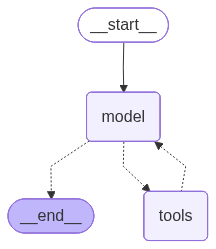

In [60]:
agent

In [61]:
user_message = 'How is the weather today in Seoul?'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

result_google = agent_google.invoke({'messages': [HumanMessage(user_message)]})  
result_anthropic = agent_anthropic.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

I’m sorry, but I can’t check live weather data directly.

If you want, I can still help in a few ways:
1. Tell you how to find today’s weather in Seoul quickly
2. Interpret a weather report if you paste it here
3. Give you a typical seasonal forecast for Seoul based on the time of year

If you’d like, I can also help you search for the current weather manually.


In [62]:
print(result_google['messages'][-1].content_blocks[-1].get('text'))  # hallucination (fail to call the tool)

I do not have access to real-time weather information. To get the most accurate and up-to-date weather forecast for Seoul today, please check a local weather website or use a weather app on your device.


In [63]:
print(result_anthropic['messages'][-1].content_blocks[-1].get('text'))

I don't have access to real-time weather data or current weather forecasts. The tools available to me are limited to searching Wikipedia for general knowledge and information, which cannot provide live weather conditions.

To check the weather in Seoul today, I recommend:

1. Using a weather website like Weather.com, Weather.gov, or your local weather service
2. Searching "Seoul weather" on Google for current conditions
3. Using a weather app on your phone
4. Checking the Korea Meteorological Administration (KMA) website for official forecasts

These sources will give you accurate, up-to-date information about Seoul's current weather, temperature, humidity, and forecasts.


In [64]:
result['messages'][1].tool_calls

[]

In [65]:
print(result_google['messages'][-1].tool_calls)
print(result_anthropic['messages'][-1].tool_calls)

[]
[]


In [66]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

How is the weather today in Seoul?
================================== Ai Message ==================================

I’m sorry, but I can’t check live weather data directly.

If you want, I can still help in a few ways:
1. Tell you how to find today’s weather in Seoul quickly
2. Interpret a weather report if you paste it here
3. Give you a typical seasonal forecast for Seoul based on the time of year

If you’d like, I can also help you search for the current weather manually.


In [67]:
for message in result_google['messages']:
    message.pretty_print()

================================ Human Message =================================

How is the weather today in Seoul?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'I do not have access to real-time weather information. To get the most accurate and up-to-date weather forecast for Seoul today, please check a local weather website or use a weather app on your device.', 'extras': {'signature': 'EvoLCvcLAQw51sdpz5dvPRpnwcFbrCDuJ2thtxIKTONsJAEFt1tOU76W2F3esu7+6ys0hU1MaCf2tZU3FcvSTHU9yvwlToBOqDBqz2/Kduit788GIToBrcTX5uaRcL2Vn73mvH7DYhB7tQN1qjK8KneHceNNuXFdpomF97i5JhUoPuL1TJG81xz1N4ZaEHE/ynmJ5ATdbO3GWQ/4JGo7ypcDip6aWD/5fDY/lcK23948nCejFvR1lra4AiD/BR5co0WhJ5VW7l8YN80CzTzAsH/q0fq6MLUhwnUXJ/CgNdouUt63WS7YWkd5crqtBWcCajux//ff3VGbPEI7wPfoRwo4orkwuwufcwqSPxSzGoW5xdsxbdr1LYovNBanh7DlcKHBuKOaN/ZKzWr6Iv19ogluUDD9/ajgmO+vHGtQifrB7k1hm2N6jOSqDymiv4brd7i8pPszF7KPx2Jndje64r0Az2sUihqw0kPnfFt5HXJV81fC4SfRQmX3kmTkjlMJCCv06ZGju7lACvxuzMGnAO9xHvyJudVb

In [68]:
for message in result_anthropic['messages']:
    message.pretty_print()

================================ Human Message =================================

How is the weather today in Seoul?
================================== Ai Message ==================================

[{'signature': 'EvAHCm0IDhgCKkCUDpTi/FU4sW8BFlOhhRX8GRF71HFv8m5z1FFrOgUC/KXwv0lyRY3IGkpTMEcYT703o+uKg4KRTMG+Uce7nDHtMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgxaFcUcLmrvbth7OE8aDBDzzbByi8k+N7rT+CIwVcL6B+9KS5pgmRjFwZPbFux/GVRIk1wojedFqbVJbqs3r3MuNp7NXSCSms7SJ3+TKrAGTzkqeBWtaoHfWsvQ/2AqshGIkPLAkgFVjMJC0ABatULcVh9VGCim1Cmt8Yu5FjC83xWuUUFoJG9VQfvv5Ixi4mhis2Q6S+17xjqYZAsr6+1T81+4Cu4i0Y4S2tba0dtpxQq56Y8zuBZW3hT73vXijlJTTVTi2yTXuKvHHhac4VwDb1Yux6iWhPgwgYmR+M+/IXuWZn3Zz3rlmfF6boPhzVGJSb9I1xrYM024u4WxjNLAgt7QRxpNTiiaj70NYIjviOSgV0uDZpCQQfo7h2GY8IwAlGplpQffI7I3g5mx2qzzpGYrGNIqzQMTsG5IySrORRgHY/ukqJq67QdD/fatu1u0wPNrOUOmaTKstNIfOU2cskdetvnJP0OL00vJIdrnzRkbfqMG/84113OqiNuiMX9zXct9yFgFyZcLdLTpILL/BSrL0Iid75kcrfbshJu1PnmVJqVwZIWofnTy6c0YRwNW1GSBENduoXqlgUxLVurwSuGiJx/V3i4oBtZQr/gD++/gqjLgoAIFY

In [69]:
user_message = '강감찬에 대한 설명을 해주세요.'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

result_google = agent_google.invoke({'messages': [HumanMessage(user_message)]})  
result_anthropic = agent_anthropic.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

강감찬은 고려 전기의 대표적인 문신이자 명장으로, 특히 귀주대첩을 이끈 인물로 잘 알려져 있습니다.

간단히 정리하면:
- 이름: 강감찬(姜邯贊)
- 생몰: 948년 ~ 1031년
- 본관: 금주
- 고려의 문관으로 과거에 장원급제했으며, 관직을 거쳐 높은 자리까지 올랐습니다.
- 가장 유명한 업적은 1019년 거란의 3차 침입을 막아낸 귀주대첩입니다.
- 이 승리로 고려는 거란의 침략을 효과적으로 저지할 수 있었습니다.
- 시호는 인헌입니다.

강감찬은 단순히 전쟁을 잘 치른 장수가 아니라, 문신으로서도 뛰어난 인물이었다는 점이 중요합니다. 학문과 행정 능력을 바탕으로 국가를 이끈 대표적인 인물로 평가됩니다.

원하시면 제가 이어서
1. 귀주대첩의 과정
2. 강감찬의 생애
3. 강감찬의 역사적 평가
중 하나를 더 자세히 설명해드릴게요.


In [70]:
result['messages'][1].tool_calls

[{'name': 'wiki_search',
  'args': {'query': '강감찬'},
  'id': 'call_zgne66jEtB01acvvmxWKYA0D',
  'type': 'tool_call'}]

In [71]:
result_google['messages'][1].tool_calls  

[{'name': 'wiki_search',
  'args': {'query': '강감찬'},
  'id': '28c76de6-1b4c-4879-9227-5c7064de4353',
  'type': 'tool_call'}]

In [72]:
result_anthropic['messages'][1].tool_calls

[{'name': 'wiki_search',
  'args': {'query': '강감찬'},
  'id': 'toolu_01LtMkAgtuUH66uBNNktXr3V',
  'type': 'tool_call'}]

In [73]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

강감찬에 대한 설명을 해주세요.
================================== Ai Message ==================================
Tool Calls:
  wiki_search (call_zgne66jEtB01acvvmxWKYA0D)
 Call ID: call_zgne66jEtB01acvvmxWKYA0D
  Args:
    query: 강감찬
================================= Tool Message =================================
Name: wiki_search

강감찬(姜邯贊 또는 姜邯瓚, 948년 음력 11월 19일~1031년 음력 8월 20일)은 고려의 문관이다. 본관은 금주(衿州)이다.
983년(성종 3) 과거에 장원급제하여 예부시랑(禮部侍郞), 한림학사를 거쳐 평장사가 되었다. 요나라의 3차 침입을 격퇴하였고, 1019년(현종 10년)에 검교태위 문하시랑 동내사 문하평장사 천수현 개국남 식읍삼백호(檢校太尉門下侍郞同內史門下平章事天水縣開國男食邑三百戶)에 봉해졌다. 1020년(현종 11년)에  특진 검교태부 천수현개국자 식읍오백호(特進檢校太傅天水縣開國子食邑五)가 되었고 1030년(현종 21년)에 문하시중이 되고 1031년(현종 22년)에 특진 검교태사 시중 천수군개국후(特進檢校太師侍中天水郡開國侯에 이르렀다. 시호는 인헌(仁憲)이다. 현종의 묘정(廟廷)에 배향되고 문종(文宗) 때 수태사(守太師) 겸 중서령(中書令)에 추증되었다.
================================== Ai Message ==================================

강감찬은 고려 전기의 대표적인 문신이자 명장으로, 특히 귀주대첩을 이끈 인물로 잘 알려져 있습니다.

간단히 정리하면:
- 이름: 강감찬(姜邯

In [74]:
for message in result_google['messages']:
    message.pretty_print()

================================ Human Message =================================

강감찬에 대한 설명을 해주세요.
================================== Ai Message ==================================

[]
Tool Calls:
  wiki_search (28c76de6-1b4c-4879-9227-5c7064de4353)
 Call ID: 28c76de6-1b4c-4879-9227-5c7064de4353
  Args:
    query: 강감찬
================================= Tool Message =================================
Name: wiki_search

강감찬(姜邯贊 또는 姜邯瓚, 948년 음력 11월 19일~1031년 음력 8월 20일)은 고려의 문관이다. 본관은 금주(衿州)이다.
983년(성종 3) 과거에 장원급제하여 예부시랑(禮部侍郞), 한림학사를 거쳐 평장사가 되었다. 요나라의 3차 침입을 격퇴하였고, 1019년(현종 10년)에 검교태위 문하시랑 동내사 문하평장사 천수현 개국남 식읍삼백호(檢校太尉門下侍郞同內史門下平章事天水縣開國男食邑三百戶)에 봉해졌다. 1020년(현종 11년)에  특진 검교태부 천수현개국자 식읍오백호(特進檢校太傅天水縣開國子食邑五)가 되었고 1030년(현종 21년)에 문하시중이 되고 1031년(현종 22년)에 특진 검교태사 시중 천수군개국후(特進檢校太師侍中天水郡開國侯에 이르렀다. 시호는 인헌(仁憲)이다. 현종의 묘정(廟廷)에 배향되고 문종(文宗) 때 수태사(守太師) 겸 중서령(中書令)에 추증되었다.
================================== Ai Message ==================================

[{'type': 'text', 'text': '강감찬(948년 ~ 1031년)은 고려 시대의 대표적인 문신이

In [75]:
for message in result_anthropic['messages']:
    message.pretty_print()

================================ Human Message =================================

강감찬에 대한 설명을 해주세요.
================================== Ai Message ==================================

[{'signature': 'EtADCm0IDhgCKkB09Hz2gWbLsZoBFIllNyx8XAiTmJAR5t2n7uSOHyHgPU1tR4ncISHWvEvZ4uDmjhReAFLzfVrkTpEplhdt9YEXMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOABCCHRoaW5raW5nEgz7GoHQfojYBQdFMHEaDDNNnZm9NHdkwYl97SIwuLRHtJ2isKAsNxhbnN3jv7mbnwsMX5awsMj8kpk/xDA4Lf/pfXZKq0hNPZ7ZuQV1KpACujUS3G1DuSGH8DQdTXcExH37VHNbZXfQciUYJJILgsj/t8cg4VgaPDdwuwf7Wndv01lGu+mhwgjORmTFB8nzgLoMrW/JKJ5bTXfNcS2rAnjphhqWg4fLEOhhYq81JAx4VcyP4ozVVR07EgHwtRjAHD3A0KBsWVXJek5q8fiU7TXPhFgJlJWeoiqLCPeGfK23uT0EyYw9S92g7igClawoyNr+tUMLcrmlnf+0xQLm3XiL96quy3lPnL50CYOfHsSzFfqoyzkwTlGsMV5AVLDcZDEg098bM1SfWQ864pB/ckScmf9kIKq68tUDynsi9lAf0E08Mj7ht3AMs/finS2+lVpVD5qz7FO7dOgGdlEsAQIYAQ==', 'thinking': '사용자가 강감찬에 대한 설명을 요청했습니다. 강감찬은 한국 역사 인물이므로 위키피디아에서 정보를 찾아서 제공하겠습니다. 한국어로 된 쿼리이므로 한국 위키피디아에서 검색될 것입니다.', 'type': 'thinking'}, {'id': 'toolu_01LtMkAgtuUH66uBNNkt

In [76]:
from langchain.messages import AIMessage

user_message = '강감찬에 대한 설명을 해주세요.'
for state in agent.stream(
    {'messages': [HumanMessage(user_message)]},
    stream_mode='messages'
):
    msg, _ = state
    if isinstance(msg, AIMessage) and not getattr(msg, 'tool_calls', []):
        if blocks := msg.content_blocks:  
            for block in blocks:
                if block.get('type') == 'text':
                    print(block.get('text', ''), end='', flush=True)
                    break
        elif msg.content:  
            print(msg.content, end='', flush=True)    

강감찬(948~1031)은 고려 시대의 대표적인 문신이자 명장입니다. 본관은 금주이며, 983년 과거에 장원급제한 뒤 관직에 올라 예부시랑, 한림학사, 평장사 등을 지냈습니다.

가장 잘 알려진 업적은 거란(요나라)의 3차 침입을 막아낸 일입니다. 특히 1019년 귀주대첩에서 고려군을 이끌어 거란군을 크게 격퇴하여 나라를 지킨 공으로 유명합니다.

이후에도 높은 관직에 올랐으며, 1031년에 세상을 떠났습니다. 시호는 인헌입니다. 강감찬은 고려의 국가 방어를 상징하는 인물로 오늘날까지도 큰 존경을 받고 있습니다.

원하시면 제가
1. 귀주대첩 중심으로 더 자세히 설명하거나
2. 강감찬의 생애를 연표로 정리해드릴 수 있습니다.

# Lab: 현재 디렉토리 파일 목록 도구를 가진 에이전트 만들기

- - -
**목표**
- 실습에서 사용한 `create_agent`와 `wiki_search` 도구에 더해, **현재 작업 디렉토리의 파일 및 폴더 목록을 반환하는 도구**를 하나 구현한다.  
- 그 도구를 가진 에이전트에게 '현재 폴더에 어떤 파일들이 있습니까?' (또는 '지금 작업 디렉토리에 무엇이 있습니까?')라고 물어보면, **해당 도구를 사용해 실제 디렉토리 내용**을 답하도록 한다.

**요구사항**
1. **실험**(아래 이미 구현했음): 파일 목록 도구를 **추가하기 전** 에이전트(실습에서 만든 `create_agent(tools=[wiki_search])`)에게 '현재 폴더에 어떤 파일들이 있습니까?'를 물어보고, 그 응답을 확인한다. (LLM은 사용자 환경을 알 수 없으므로 정확히 답하지 못한다.)
2. **파일 목록 도구**: **현재 작업 디렉토리(cwd)의 파일과 폴더 이름 목록**을 반환하는 도구를 구현한다. 도구의 이름과 설명(description)은 에이전트가 '파일 목록', '디렉토리 내용', '현재 폴더' 관련 질문에 이 도구를 선택할 수 있도록 구체적으로 작성한다.
3. **에이전트에 반영**: 위 도구를 `wiki_search`(Wikipedia 검색)와 함께 `create_agent`에 넣어, `tools=[wiki_search, 파일목록_도구]` 형태로 에이전트를 만든다.
4. **동작 확인**: 같은 질문('현재 폴더에 어떤 파일들이 있습니까?')을 **파일 목록 도구를 추가한 에이전트**에게 넣어, 도구를 호출하고 **실제 디렉토리 내용**이 최종 답에 포함되는지 확인한다. (필요하면 `tool_calls`나 최종 메시지를 출력해 보여도 된다.)

**제출 안내**        
- 제출 파일은 `.ipynb` 노트북 파일이다.
- 기존 실습 코드 아래에 과제 코드를 추가하여 제출한다.
- 코드를 모르는 사람도 이해할 수 있도록 코드에 친절하고 상세한 주석을 포함한다.

<details>
<summary><b>클릭하여 💡힌트 보기</b></summary>

- 실습에서 사용한 LangChain의 `@tool` 데코레이터로 함수를 감싸 도구를 정의하면, `wiki_search` 도구와 같은 방식으로 에이전트에 등록할 수 있다.
- 현재 디렉토리 목록은 Python 표준 라이브러리 `pathlib` (예: `list(Path('.').iterdir())`) 또는 `os` (예: `os.listdir('.')`)를 사용하면 구할 수 있다.
- `description`에 '현재 폴더', '파일 목록', '디렉토리', '작업 디렉토리' 같은 표현을 넣어 두면, 에이전트가 이 도구를 고르기 쉽다.
- 실습의 `wiki_search` 도구 정의 방식을 참고해, 전달인자는 필요 시에만 두고(없으면 현재 디렉토리 기준), 반환은 문자열(예: 줄바꿈으로 구분한 파일명 목록)로 하면 된다.

</details>

- - -

**실험: 파일 목록 도구 없이 에이전트에게 현재 폴더 내용 물어보기**

실습에서 만든 에이전트(`create_agent(tools=[wiki_search])`)는 파일 목록 도구가 없으므로, '현재 폴더에 어떤 파일들이 있습니까?'에 답하지 못한다. LLM은 사용자 컴퓨터의 파일 시스템에 접근할 수 없다.

In [82]:
# --- 파일 목록 도구 없이 에이전트에게 현재 폴더 내용을 물어본다.
from langchain.messages import HumanMessage

user_message = '현재 폴더에 어떤 파일들이 있습니까?'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

제가 현재 사용자의 컴퓨터에 직접 접근할 수 없어 현재 폴더 내용을 확인할 수 없습니다. 대신 사용 중인 환경에 따라 직접 실행할 수 있는 명령들을 알려드릴게요. 원하시면 명령 결과를 붙여넣어 주시면 제가 분석해 드립니다. 어떤 운영체제인지(Windows / macOS / Linux)와 숨김 파일 포함 여부, 하위 폴더까지 재귀적으로 볼지 알려주세요.

Linux / macOS (터미널)
- 기본 목록(숨김 제외): ls
- 상세 목록(숨김 포함): ls -la
- 사람 읽기 쉬운 용량 표시: ls -lh
- 재귀적으로 전체 트리(설치 필요할 수 있음): tree -a
- 현재 폴더의 파일만(디렉터리 제외): find . -maxdepth 1 -type f -print

Windows 명령 프롬프트 (cmd)
- 목록(현재 폴더): dir
- 숨김 포함: dir /a

Windows PowerShell
- 목록(기본): Get-ChildItem
- 숨김 포함: Get-ChildItem -Force
- 파일만: Get-ChildItem -File
- 재귀: Get-ChildItem -Recurse

Python (터미널이나 스크립트)
- 간단히: python -c "import os; print('\n'.join(os.listdir('.')))"
- pathlib 사용: python -c "from pathlib import Path; print('\n'.join(p.name for p in Path('.').iterdir()))"

Node.js
- 터미널에서: node -e "const fs=require('fs');console.log(fs.readdirSync('.').join('\n'))"

Jupyter 노트북
- 셀에: !ls -la  (리눅스/맥 커널인 경우)
- Windows 커널일 경우: !dir

VS Code 통합 터미널
- 일반 터미널 명령(ls / dir / PowerShell 명령) 사용

원하시면 바로 실행할 명령을 추천해 드리거나,

In [ ]:
# YOUR CODE HERE

In [86]:
user_message = '현재 폴더에 어떤 파일들이 있습니까?'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

현재 폴더에 다음 항목들이 있습니다:

- .ipynb_checkpoints/  (디렉터리)
- 01(00-1)_langchain-a-quick-walkthrough.ipynb
- 01(00-1d)_langchain-a-quick-walkthrough.ipynb
- 01(00-1s)_langchain-a-quick-walkthrough-sol.ipynb
- 02(00-3)_structured-outputs.ipynb
- 02(00-3d)_structured-outputs.ipynb
- 02(00-3s)_structured-outputs-sol.ipynb


In [87]:
result['messages'][1].tool_calls

[{'name': 'list_directory',
  'args': {},
  'id': 'call_nUEVGudbZLh19TQqCjcvEa8W',
  'type': 'tool_call'}]

In [88]:
user_message = '강감찬에 대한 설명을 해주세요.'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

강감찬(姜邯贊, 948년–1031년)은 고려 중기의 대표적인 문신이자 군인으로, 특히 1019년의 귀주대첩으로 널리 알려진 국난 극복의 영웅입니다.

주요 약력 및 업적
- 출생·사망: 948년 음력 11월 19일 출생, 1031년 음력 8월 20일 사망(기년은 일부 자료에 따라 표기가 다름).
- 관력: 983년(성종 3) 과거에 장원급제한 뒤 예부시랑, 한림학사 등 문관을 거쳐 평장사(국정의 핵심 관직)에 올랐습니다. 말년에는 문하시중 등 고관을 역임했고, 사후에는 시호 인헌(仁憲)을 받았습니다.
- 귀주대첩(1019년, 현종 10년): 거란(요나라)의 3차 침입을 맞아 강감찬이 지휘하여 귀주(현재의 북청·황주 지역 등)에서 대승을 거두었습니다. 이 승리는 거란의 대규모 침략을 격퇴하고 고려의 안보를 지킨 결정적 전투로 평가됩니다.
- 전술적 성과: 기동과 기습, 지형·수리(수로 활용) 등을 이용한 전술로 적의 주력에 큰 피해를 주어 전세를 뒤집었습니다(전투 세부 전술은 사료마다 차이가 있음).

사후와 유산
- 문종 때까지 여러 차례 추증과 배향을 받았고, 국왕의 묘정에 배향되는 등 높은 예우를 받았습니다.
- 기념물·지명: 서울 관악구의 낙성대는 강감찬의 출생지로 전해지며, 그의 업적을 기려 공원이 조성되어 있습니다.
- 현대적 기념: 대한민국 해군 구축함 DDH-979 강감찬 등으로 이름이 계승되어 국가적 영웅으로 기억됩니다.
- 문화적 영향: 역사서·기념비·문학·드라마 등에서 자주 다뤄지며, 민족적 자부심을 상징하는 인물입니다.

의미
- 귀주대첩을 통한 국난 극복으로 고려의 존립을 유지한 전략·지휘 능력과 문무(文武)를 겸비한 이상적 관료·장수로 평가됩니다.

더 자세한 연대기나 전투 전술, 관련 유적·문헌에 대한 정보를 원하시면 어느 부분을 더 알고 싶은지 알려주세요.


In [81]:
result['messages'][1].tool_calls

[{'name': 'wiki_search',
  'args': {'query': '강감찬'},
  'id': 'call_cuQpCiQ0LCnFPDuP05YPD3KZ',
  'type': 'tool_call'}]

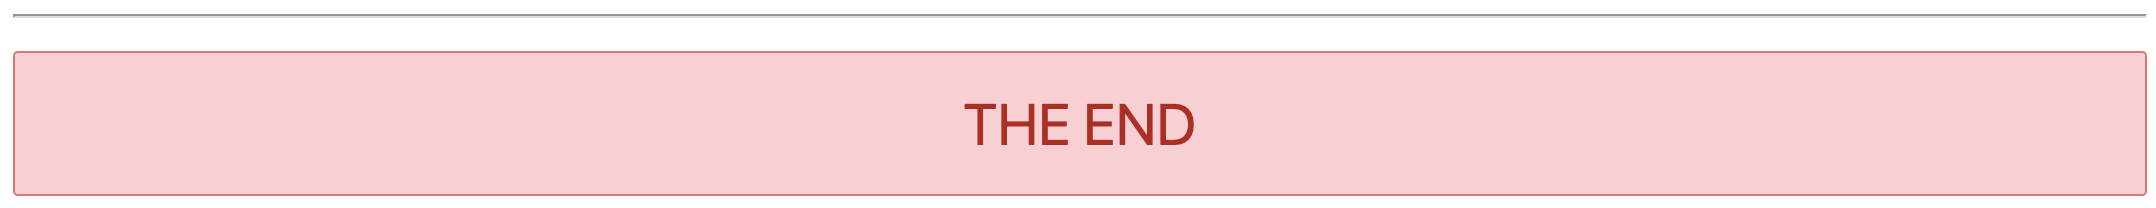